In [1]:
# Adapted from https://github.com/elstonlab/PhagocytosisRosetteModel/blob/main/WPGAP_FP_Check_EA_Results.ipynb by J. Cody Herron
import numpy as np
from scipy.integrate import odeint
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [2]:
folder = os.getcwd()
file_loc = folder

threshold_good_score = 50 # Threshold for fitness function to be considered as a successful round of parameter searching
path, dirs, files = os.walk(file_loc).__next__()
len_files = 501 # Total number of rounds of parameter searching

runs_df = pd.DataFrame(index = range(len_files), columns=['Score','a_act', 'd_act', 'K_n', 'n', 'a_x', 'd_x', 'm',
                                                          'K_S', 'K_a', 'k1', 'k2', 'k4', 'k3', 'XbsT', 'sT']) # Load optimized parameters
best_scores = []
best_inds = []
plt.figure(figsize=(5,3))
for i in range(len_files):
    logbook = pickle.load( open( folder + '/' + str(i) + ".pickled", "rb" ) )
    runs_df.iloc[i] = np.insert(logbook[1][-1],0,logbook[0][-1])
        
    best_scores.append(logbook[0][-1])
    best_inds.append(logbook[1][-1])
  
    run = np.array(logbook[0])
    score = logbook[0][-1]

<Figure size 500x300 with 0 Axes>

In [3]:
good_df = runs_df[runs_df['Score'] < threshold_good_score].sort_values('Score')

In [4]:
good_df

,Score,a_act,d_act,K_n,n,a_x,d_x,m,K_S,K_a,k1,k2,k4,k3,XbsT,sT
3,16.239691,0.179848,0.362697,1.307348,6.295737,3.846481,0.005412,3.494532,1.00324,3.761911,0.000589,1.38282,7.339447,0.011614,100.000957,80.960927
236,17.637216,0.744847,0.251048,1.000059,9.839469,9.091577,0.031623,4.423232,1.00626,4.407289,0.000932,2.289235,0.391011,0.00056,100.000001,88.758103
370,18.176918,1.776925,8.623968,1.953543,6.338844,2.814366,0.03129,2.737109,1.177819,1.289472,0.000665,0.250762,0.714439,0.000101,100.047653,317.707332
290,18.320567,57.776063,1.357981,2.000112,8.263569,1.950294,0.022929,2.106339,1.0112,83.887465,0.000354,0.387236,38.793051,0.103412,100.116158,76.357888
255,18.558914,25.87469,3.359742,2.848831,8.074003,9.736316,0.006531,2.816685,1.283401,293.450952,0.000578,0.845882,0.271854,0.000366,100.002822,140.796537
85,19.512062,12.701604,0.550246,4.261195,9.99173,9.370875,0.028009,2.758593,1.890289,320.61777,0.000873,0.338997,4.885862,0.001274,100.726391,228.797323
401,20.173832,0.17786,0.03311,1.023912,2.650231,4.064776,0.006874,3.810486,1.293793,11.27768,0.000122,0.232292,2.195181,0.000511,100.164864,192.018135
392,20.17862,18.847551,4.822742,1.016362,9.305485,8.680927,0.015248,3.199229,1.079267,28.728874,0.003029,8.44564,39.373285,0.073718,100.000179,125.03667
475,20.458168,3.696197,0.036271,4.666028,1.076292,8.989162,0.022399,1.697054,1.024381,263.945226,0.000973,5.553706,15.10221,0.045524,100.018677,97.180721
307,20.999969,3.215996,1.984489,2.228717,2.354977,9.999228,0.014554,1.696247,1.000534,3.275778,0.000497,4.97549,38.183011,0.000238,101.637862,1766.239201


In [8]:
def DE1(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b)*(N_S*x1b - s1b)  - k4*s1b
        ]
    return dy

In [9]:
def DE2(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b, x2f, x2b, s2b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) + a_act/(1 +(s2b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b - s2b)*(N_S*x1b - s1b)  - k4*s1b,
        a_x*act/(K_a + act) - d_x*x2f - k1*(XbsT - x2b)*x2f + k2*x2b/(1+(s2b/K_S)**m),
        k1*(XbsT - x2b)*x2f - k2*x2b/(1+(s2b/K_S)**m),
        k5*(sT - s1b - s2b)*(N_S*x2b - s2b)  - k4*s2b,
        ]
    return dy

In [10]:
def DE3(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b, x2f, x2b, s2b, x3f, x3b, s3b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) + a_act/(1 +(s2b/K_n)**n) + a_act/(1 +(s3b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x1b - s1b)  - k4*s1b,
        a_x*act/(K_a + act) - d_x*x2f - k1*(XbsT - x2b)*x2f + k2*x2b/(1+(s2b/K_S)**m),
        k1*(XbsT - x2b)*x2f - k2*x2b/(1+(s2b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x2b - s2b)  - k4*s2b,
        a_x*act/(K_a + act) - d_x*x3f - k1*(XbsT - x3b)*x3f + k2*x3b/(1+(s3b/K_S)**m),
        k1*(XbsT - x3b)*x3f - k2*x3b/(1+(s3b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x3b - s3b)  - k4*s3b
        ]
    return dy

In [41]:
IC = [0,  #act;
          0,  #x1f;
          0,  #x1b;
          0,  #s1b;
         ]
final_time = 5000
dt = 0.01
n_time_point = round(final_time/dt)
time = np.linspace(0,final_time,n_time_point)
idx = []
for i in range(len(good_df)):
    param = good_df.iloc[i][1:]
    #sT = param[-1]
    #XbsT = param[-2]
    y = odeint(DE1, IC, time, args=(param,), rtol = 1e-10, atol=1e-10)
    x1b = y[:,2]
    if max(x1b) - (x1b[-1])>=5:
        idx.append(i)
new_df = good_df.iloc[idx,:]
new_df.to_csv('New_parameters_for_activator_depletion_transient_signal.csv', index=False)

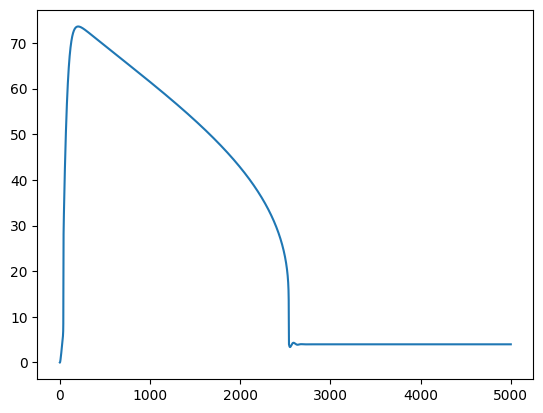

In [57]:
param = new_df.iloc[0][1:]
y = odeint(DE1, IC, time, args=(param,), rtol = 1e-10, atol=1e-10)
x1b = y[:,2]
plt.figure()
plt.plot(time, x1b)
plt.show()

In [53]:
new_df

,Score,a_act,d_act,K_n,n,a_x,d_x,m,K_S,K_a,k1,k2,k4,k3,XbsT,sT
197,23.413492,2.254566,0.029591,1.000655,9.951358,2.215545,0.028325,3.948216,2.621333,21.828184,0.023525,9.893576,38.865072,0.373086,100.107269,51.033055
409,29.254564,2.124826,0.368223,1.256942,9.70239,8.961311,0.016076,1.511834,1.001655,16.768339,0.005895,9.793096,15.314893,0.554392,100.005611,53.403686
408,42.43854,0.898319,0.002729,1.027388,2.324308,3.34031,0.019673,2.867634,7.127476,67.601608,0.001533,1.045429,0.225475,0.201448,100.176231,65.209937
397,43.482979,39.067926,0.633441,1.378927,3.308129,3.863379,0.014101,3.590051,9.044499,2.157488,0.04155,8.403137,31.781814,8.64477,100.004737,52.397206
